Files already downloaded and verified


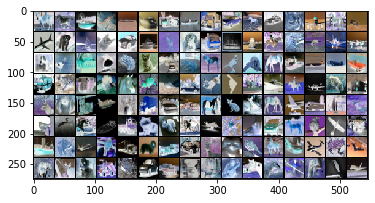

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

batch_size = 128
mnist_trainset = torchvision.datasets.CIFAR10(root='C:/Users/weido/ch11/data', train=False,
                      download=True, transform=transforms.ToTensor())
Mnist = torch.utils.data.DataLoader(mnist_trainset, batch_size=batch_size,
                                         shuffle=True, num_workers=1)
def imshow_grey(img):
    plt.imshow(img.permute(1,2,0),cmap="Greys")
    plt.show()

# get some random training images
dataiter= iter(Mnist) # return an iterator assigned to dataiter
images, labels = dataiter.next() # get the current iteration on dataiter: [batch_size, C, H, W]

# show images in one batch, "255-images" 
imshow_grey(torchvision.utils.make_grid(255-images, nrow=16, normalize=True))



In [2]:
images.shape

torch.Size([128, 3, 32, 32])

In [3]:


class AlexNet(nn.Module):
    def __init__(self):   # define self functions for all layers with learning parameters
        super(AlexNet, self).__init__()   
        self.conv1 = nn.Conv2d(3,96,11, stride=4, padding=2)  # define function sefl.conv1 for Conv layer1
        self.conv2 = nn.Conv2d(96,256,5, padding=2)
        self.conv3 = nn.Conv2d(256,384,3, padding=1)
        self.conv4 = nn.Conv2d(384,384,3, padding=1)
        self.conv5 = nn.Conv2d(384,256,3, padding=1)
        self.fc1 = nn.Linear(256*6*6, 4096)
        self.fc2 = nn.Linear(4096,4096)
        self.fc3 = nn.Linear(4096,1000)
        
    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x,3,2)
        
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x,3,2)
        
        x = self.conv3(x)
        x = F.relu(x)
        
        x = self.conv4(x)
        x = F.relu(x)
        
        x = self.conv5(x)
        x = F.relu(x)
        x = F.max_pool2d(x,3,2)
    
        x = x.view(-1, 256*6*6)
        x = self.fc1(x)
        x = F.relu(x)
        x = F.dropout(x,0.5)
        
        x = self.fc2(x)
        x = F.relu(x)
        x = F.dropout(x,0.5)
        
        x = self.fc3(x)
        return x
    
net = AlexNet()

In [4]:
X = torch.randn(4, 3, 224, 224)
out=net(X) 

In [5]:
out.shape


torch.Size([4, 1000])

In [6]:
numel_list = [p.numel() for p in net.parameters() if p.requires_grad == True]
sum(numel_list), numel_list

(62378344,
 [34848,
  96,
  614400,
  256,
  884736,
  384,
  1327104,
  384,
  884736,
  256,
  37748736,
  4096,
  16777216,
  4096,
  4096000,
  1000])

In [7]:
class VGG16(nn.Module):
    def __init__(self):
        super(VGG16, self).__init__()
        self.conv1_1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(64, 64, 3, padding=1)

        self.conv2_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv2_2 = nn.Conv2d(128, 128, 3, padding=1)

        self.conv3_1 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv3_2 = nn.Conv2d(256, 256, 3, padding=1)
        self.conv3_3 = nn.Conv2d(256, 256, 3, padding=1)

        self.conv4_1 = nn.Conv2d(256, 512, 3, padding=1)
        self.conv4_2 = nn.Conv2d(512,512, 3, padding=1)
        self.conv4_3 = nn.Conv2d(512, 512, 3, padding=1)

        self.conv5_1 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_2 = nn.Conv2d(512, 512, 3, padding=1)
        self.conv5_3 = nn.Conv2d(512, 512, 3, padding=1)

        self.fc1 = nn.Linear(25088, 4096)
        self.fc2 = nn.Linear(4096, 4096)
        self.fc3 = nn.Linear(4096, 1000)

    def forward(self, x):
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = F.max_pool2d(x,2)
        #--------
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = F.max_pool2d(x,2)
        #--------
        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = F.relu(self.conv3_3(x))
        x = F.max_pool2d(x,2)
        #---------
        x = F.relu(self.conv4_1(x))
        x = F.relu(self.conv4_2(x))
        x = F.relu(self.conv4_3(x))
        x = F.max_pool2d(x,2)
        #------
        x = F.relu(self.conv5_1(x))
        x = F.relu(self.conv5_2(x))
        x = F.relu(self.conv5_3(x))
        x = F.max_pool2d(x,2)
        #------
        x = x.reshape(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, 0.5) #dropout was included to combat overfitting
        x = F.relu(self.fc2(x))
        x = F.dropout(x, 0.5)
        x = self.fc3(x)
        return x

In [8]:
net_VGG16=VGG16()
out=net_VGG16(X) 
print(out.shape)

torch.Size([4, 1000])


In [9]:
numel_list = [p.numel() for p in net_VGG16.parameters() if p.requires_grad == True]
sum(numel_list), numel_list

(138357544,
 [1728,
  64,
  36864,
  64,
  73728,
  128,
  147456,
  128,
  294912,
  256,
  589824,
  256,
  589824,
  256,
  1179648,
  512,
  2359296,
  512,
  2359296,
  512,
  2359296,
  512,
  2359296,
  512,
  2359296,
  512,
  102760448,
  4096,
  16777216,
  4096,
  4096000,
  1000])

In [10]:
class NiN(nn.Module):
    def __init__(self, num_labels):
        super(NiN, self).__init__()
        self.net = nn.Sequential(
            #nin_block(self, in_channels, out_channels, kernel_size, stride, padding):
            self.nin_block(3, 96, 11, stride=4, padding=0),
            nn.Dropout(p=0.5),
            nn.MaxPool2d(kernel_size=3, stride=2),
            self.nin_block(96, 256, 5, stride=1, padding=2),
            nn.Dropout(p=0.5),
            nn.MaxPool2d(kernel_size=3, stride=2),
            self.nin_block(256, 384, 3, stride=1, padding=1),
            nn.Dropout(p=0.5),
            nn.MaxPool2d(kernel_size=3, stride=2),
            self.nin_block(384, num_labels, 3, stride=1, padding=1),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        self.init_weight()

    def forward(self,x):
        return self.net(x)

    def init_weight(self):
        for layer in self.net:
            if isinstance(layer, nn.Conv2d):
                nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
                nn.init.constant_(layer.bias, 0)

    def nin_block(self, in_channels, out_channels, kernel_size, stride, padding):
        return nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size,stride=stride,padding=padding),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )

    def test_output_shape(self):
        test_img = torch.rand(size=(1, 3, 224, 224), dtype=torch.float32)
        for layer in self.net:
            test_img = layer(test_img)
            print(layer.__class__.__name__, 'output shape: \t', test_img.shape)

nin = NiN(num_labels=1000)
nin.test_output_shape()

Sequential output shape: 	 torch.Size([1, 96, 54, 54])
Dropout output shape: 	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape: 	 torch.Size([1, 96, 26, 26])
Sequential output shape: 	 torch.Size([1, 256, 26, 26])
Dropout output shape: 	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape: 	 torch.Size([1, 256, 12, 12])
Sequential output shape: 	 torch.Size([1, 384, 12, 12])
Dropout output shape: 	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape: 	 torch.Size([1, 384, 5, 5])
Sequential output shape: 	 torch.Size([1, 1000, 5, 5])
AdaptiveAvgPool2d output shape: 	 torch.Size([1, 1000, 1, 1])
Flatten output shape: 	 torch.Size([1, 1000])


In [11]:
numel_list = [p.numel() for p in nin.parameters() if p.requires_grad == True]
sum(numel_list), numel_list

(7439608,
 [34848,
  96,
  9216,
  96,
  9216,
  96,
  614400,
  256,
  65536,
  256,
  65536,
  256,
  884736,
  384,
  147456,
  384,
  147456,
  384,
  3456000,
  1000,
  1000000,
  1000,
  1000000,
  1000])

In [12]:
from torchvision import models     # import package models

In [13]:
dir(models)  # display different models

['AlexNet',
 'DenseNet',
 'GoogLeNet',
 'GoogLeNetOutputs',
 'Inception3',
 'InceptionOutputs',
 'MNASNet',
 'MobileNetV2',
 'ResNet',
 'ShuffleNetV2',
 'SqueezeNet',
 'VGG',
 '_GoogLeNetOutputs',
 '_InceptionOutputs',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_utils',
 'alexnet',
 'densenet',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'detection',
 'googlenet',
 'inception',
 'inception_v3',
 'mnasnet',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet',
 'mobilenet_v2',
 'quantization',
 'resnet',
 'resnet101',
 'resnet152',
 'resnet18',
 'resnet34',
 'resnet50',
 'resnext101_32x8d',
 'resnext50_32x4d',
 'segmentation',
 'shufflenet_v2_x0_5',
 'shufflenet_v2_x1_0',
 'shufflenet_v2_x1_5',
 'shufflenet_v2_x2_0',
 'shufflenetv2',
 'squeezenet',
 'squeezenet1_0',
 'squeezenet1_1',
 'utils',
 'vgg',
 'vgg11',
 'vgg11_bn',
 'vgg13',
 'vgg13_bn',
 'vgg16',
 'vg

In [14]:
googlenet = models.googlenet(pretrained = True)

In [15]:
from torchsummary import summary

In [16]:
summary(googlenet, (3,224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
       BasicConv2d-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
       BasicConv2d-7           [-1, 64, 56, 56]               0
            Conv2d-8          [-1, 192, 56, 56]         110,592
       BatchNorm2d-9          [-1, 192, 56, 56]             384
      BasicConv2d-10          [-1, 192, 56, 56]               0
        MaxPool2d-11          [-1, 192, 28, 28]               0
           Conv2d-12           [-1, 64, 28, 28]          12,288
      BatchNorm2d-13           [-1, 64, 28, 28]             128
      BasicConv2d-14           [-1, 64,

In [17]:
print(googlenet)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [18]:
resnet18 = models.resnet18(pretrained = True)

In [19]:
print(resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
summary(resnet18, (3,224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [21]:
# instantiate a pretrained model alexnet
alexnet = models.alexnet(pretrained=True) 

In [22]:
print(alexnet) # print the architecture of Alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [23]:
summary (alexnet, (3,224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 55, 55]          23,296
              ReLU-2           [-1, 64, 55, 55]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
AdaptiveAvgPool2d-14            [-1, 25

In [24]:
transform = transforms.Compose([            #[1]
 transforms.Resize(256),                    #[2]
 transforms.CenterCrop(224),                #[3]
 transforms.ToTensor(),                     #[4]
 transforms.Normalize(                      #[5]
 mean=[0.485, 0.456, 0.406],                #[6]
 std=[0.229, 0.224, 0.225]                  #[7]
 )])


In [44]:
from PIL import Image
#img = Image.open("C:/machine_learning/NN_dnn/dog.jpg")
img = Image.open("cat.jpg")

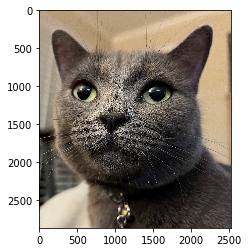

In [45]:
plt.imshow(img)

In [46]:
img_t = transform(img)
batch_t = torch.unsqueeze(img_t, 0)


In [47]:
batch_t.shape

torch.Size([1, 3, 224, 224])

In [48]:
alexnet.eval()
out = alexnet(batch_t)
print(out.shape)


torch.Size([1, 1000])


In [49]:
with open('imagenet_classes.txt') as f:
  classes = [line.strip() for line in f.readlines()]


In [50]:
_, index = torch.max(out, 1)
percentage = torch.nn.functional.softmax(out, dim=1)[0] * 100
print(classes[index[0]], percentage[index[0]].item())


Egyptian cat 21.715721130371094


In [51]:
percentage.shape

torch.Size([1000])

In [52]:
_, indices = torch.sort(out, descending=True)
[(classes[idx], percentage[idx].item()) for idx in indices[0][:5]]


[('Egyptian cat', 21.715721130371094),
 ('Siamese cat', 20.509252548217773),
 ('lynx', 20.28806495666504),
 ('tabby', 11.527338027954102),
 ('bow tie', 7.61397647857666)]

In [34]:
list(alexnet.modules())

[AlexNet(
   (features): Sequential(
     (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
     (1): ReLU(inplace=True)
     (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
     (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
     (4): ReLU(inplace=True)
     (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
     (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (7): ReLU(inplace=True)
     (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (9): ReLU(inplace=True)
     (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
     (11): ReLU(inplace=True)
     (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
   )
   (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
   (classifier): Sequential(
     (0): Dropout(p=0.5, inplace=False)
     (1): Linear(in_features=9216, out_feature

In [35]:
i=0
for (name, module) in alexnet.named_modules():
    i=i+1
    print(i,name, module)
  

1  AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True

In [36]:
for (name, module) in alexnet.named_children():
    print(name, module)

features Sequential(
  (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (4): ReLU(inplace=True)
  (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (7): ReLU(inplace=True)
  (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): ReLU(inplace=True)
  (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
)
avgpool AdaptiveAvgPool2d(output_size=(6, 6))
classifier Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=F

In [37]:
for (name, module) in alexnet.named_children():
    if name == 'classifier':
        for layer in module:
            print(layer)
            for param in layer.parameters():
                print(param)


Dropout(p=0.5, inplace=False)
Linear(in_features=9216, out_features=4096, bias=True)
Parameter containing:
tensor([[ 0.0040,  0.0061,  0.0134,  ..., -0.0003, -0.0022, -0.0093],
        [ 0.0013,  0.0020,  0.0028,  ...,  0.0053,  0.0002, -0.0145],
        [-0.0185, -0.0145, -0.0198,  ..., -0.0003, -0.0012,  0.0191],
        ...,
        [-0.0063,  0.0026, -0.0084,  ..., -0.0079,  0.0055,  0.0067],
        [-0.0115, -0.0055, -0.0092,  ..., -0.0039, -0.0048, -0.0099],
        [ 0.0026, -0.0148, -0.0016,  ...,  0.0050,  0.0052, -0.0045]],
       requires_grad=True)
Parameter containing:
tensor([ 0.0324,  0.0621, -0.0557,  ..., -0.0248,  0.0185,  0.0095],
       requires_grad=True)
ReLU(inplace=True)
Dropout(p=0.5, inplace=False)
Linear(in_features=4096, out_features=4096, bias=True)
Parameter containing:
tensor([[-0.0107, -0.0015,  0.0057,  ...,  0.0026, -0.0010, -0.0087],
        [-0.0279,  0.0168, -0.0162,  ..., -0.0079, -0.0049, -0.0219],
        [-0.0112, -0.0184,  0.0073,  ...,  0.001

In [38]:
print(module)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [39]:
for (name, module) in alexnet.named_children():
    if name == 'features':
        for (name,layer) in module.named_children():
            for param in layer.parameters():
                print(param)
            break

Parameter containing:
tensor([[[[ 1.1864e-01,  9.4069e-02,  9.5435e-02,  ...,  5.5822e-02,
            2.1575e-02,  4.9963e-02],
          [ 7.4882e-02,  3.8940e-02,  5.2979e-02,  ...,  2.5709e-02,
           -1.1299e-02,  4.1590e-03],
          [ 7.5425e-02,  3.8779e-02,  5.4930e-02,  ...,  4.3596e-02,
            1.0225e-02,  1.3251e-02],
          ...,
          [ 9.3155e-02,  1.0374e-01,  6.7547e-02,  ..., -2.0277e-01,
           -1.2839e-01, -1.1220e-01],
          [ 4.3544e-02,  6.4916e-02,  3.6164e-02,  ..., -2.0248e-01,
           -1.1376e-01, -1.0719e-01],
          [ 4.7369e-02,  6.2543e-02,  2.4758e-02,  ..., -1.1844e-01,
           -9.5567e-02, -8.3890e-02]],

         [[-7.2634e-02, -5.7996e-02, -8.0661e-02,  ..., -6.0304e-04,
           -2.5309e-02,  2.5471e-02],
          [-6.9042e-02, -6.7562e-02, -7.6367e-02,  ..., -3.9616e-03,
           -3.0402e-02,  1.0477e-02],
          [-9.9517e-02, -8.5592e-02, -1.0521e-01,  ..., -2.6587e-02,
           -2.2777e-02,  6.6451e-03]

In [40]:
in_features = alexnet._modules['classifier'][-1].in_features
out_features = 10
alexnet._modules['classifier'][-1] = nn.Linear(in_features, out_features, bias=True)
print(alexnet._modules['classifier'])

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=10, bias=True)
)


In [41]:
alexnet

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [42]:
for (name, module) in alexnet.named_children():
    if name == 'classifier':
        for layer in module.children():
            for param in layer.parameters():
                print((param))
            #print(layer)

Parameter containing:
tensor([[ 0.0040,  0.0061,  0.0134,  ..., -0.0003, -0.0022, -0.0093],
        [ 0.0013,  0.0020,  0.0028,  ...,  0.0053,  0.0002, -0.0145],
        [-0.0185, -0.0145, -0.0198,  ..., -0.0003, -0.0012,  0.0191],
        ...,
        [-0.0063,  0.0026, -0.0084,  ..., -0.0079,  0.0055,  0.0067],
        [-0.0115, -0.0055, -0.0092,  ..., -0.0039, -0.0048, -0.0099],
        [ 0.0026, -0.0148, -0.0016,  ...,  0.0050,  0.0052, -0.0045]],
       requires_grad=True)
Parameter containing:
tensor([ 0.0324,  0.0621, -0.0557,  ..., -0.0248,  0.0185,  0.0095],
       requires_grad=True)
Parameter containing:
tensor([[-0.0107, -0.0015,  0.0057,  ...,  0.0026, -0.0010, -0.0087],
        [-0.0279,  0.0168, -0.0162,  ..., -0.0079, -0.0049, -0.0219],
        [-0.0112, -0.0184,  0.0073,  ...,  0.0013,  0.0050,  0.0055],
        ...,
        [-0.0027, -0.0146,  0.0057,  ...,  0.0250, -0.0042, -0.0009],
        [ 0.0066,  0.0094,  0.0232,  ...,  0.0060, -0.0029, -0.0042],
        [ 0.01

In [43]:

for (name, module) in alexnet.named_children():
    print(name)
    for (layer_name,layer) in module.named_children():
        if name == 'classifier' and layer_name =="6":
        #if name == 'classifier' and layer == alexnet._modules['classifier'][-1] :
            for param in layer.parameters():
                param.requires_grad = True
            print('{} {} {} was NOT frozen!'.format(name, layer_name, layer))
        else:    
            for param in layer.parameters():
                param.requires_grad = False
            
            print('{} {} {} was frozen!'.format(name, layer_name, layer))


features
features 0 Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2)) was frozen!
features 1 ReLU(inplace=True) was frozen!
features 2 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False) was frozen!
features 3 Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2)) was frozen!
features 4 ReLU(inplace=True) was frozen!
features 5 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False) was frozen!
features 6 Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) was frozen!
features 7 ReLU(inplace=True) was frozen!
features 8 Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) was frozen!
features 9 ReLU(inplace=True) was frozen!
features 10 Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)) was frozen!
features 11 ReLU(inplace=True) was frozen!
features 12 MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False) was frozen!
avgpool
classifier
classifier 0

In [44]:
batch_size=32
#transform = transforms.Compose([transforms.ToTensor(),
#                               transforms.Normalize((0.5,0.5,0.5), (0.5, 0.5, 0.5))])
transform = transforms.Compose([            #[1]
 transforms.Resize(256),                    #[2]
 transforms.CenterCrop(224),                #[3]
 transforms.ToTensor(),                     #[4]
 transforms.Normalize(                      #[5]
 mean=[0.485, 0.456, 0.406],                #[6]
 std=[0.229, 0.224, 0.225]                  #[7]
 )])


In [45]:
trainset = torchvision.datasets.CIFAR10(root='C:/Users/weido/ch11/data', train=True,
                                       download=True, transform=transform)


Files already downloaded and verified


In [46]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                         shuffle=True, num_workers=2)

In [47]:
testset = torchvision.datasets.CIFAR10(root='C:/Users/weido/ch11/data', train=False,
                                       download=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                        shuffle=False, num_workers=2)

In [48]:
correct = 0
total = 0
counter=0
with torch.no_grad():
    for data in testloader:
        counter=counter+1
        print(counter)
        images, labels = data
        outputs = alexnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [49]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
#optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, alexnet.parameters()), lr=0.001)
#optimizer = optim.Adam(filter(lambda p: p.requires_grad,alexnet.parameters()), lr=0.001)

# optimizer_conv = optim.SGD(model_vgg16.parameters(), lr=0.001)
# optimizer_conv = optim.SGD(filter(lambda p: p.requires_grad, model_vgg16.parameters()), lr=0.001)

for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader,0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = alexnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        
        if i % 100 == 99:    # print every 100 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 100))
            running_loss = 0.0
        
print('Finished Training')

[1,   100] loss: 0.953
[1,   200] loss: 0.707
[1,   300] loss: 0.635
[1,   400] loss: 0.642
[1,   500] loss: 0.644
[1,   600] loss: 0.617
[1,   700] loss: 0.591
[1,   800] loss: 0.652
[1,   900] loss: 0.609
[1,  1000] loss: 0.602
[1,  1100] loss: 0.623
[1,  1200] loss: 0.603
[1,  1300] loss: 0.625
[1,  1400] loss: 0.572
[1,  1500] loss: 0.588
[2,   100] loss: 0.498
[2,   200] loss: 0.472
[2,   300] loss: 0.485
[2,   400] loss: 0.456
[2,   500] loss: 0.515
[2,   600] loss: 0.444
[2,   700] loss: 0.493
[2,   800] loss: 0.442
[2,   900] loss: 0.494
[2,  1000] loss: 0.503
[2,  1100] loss: 0.497
[2,  1200] loss: 0.473
[2,  1300] loss: 0.461
[2,  1400] loss: 0.486
[2,  1500] loss: 0.484
Finished Training


In [50]:
for (name, module) in alexnet.named_children():
    if name == 'classifier':
        for layer in module.children():
            for param in layer.parameters():
                print((param))

Parameter containing:
tensor([[ 0.0040,  0.0061,  0.0134,  ..., -0.0003, -0.0022, -0.0093],
        [ 0.0013,  0.0020,  0.0028,  ...,  0.0053,  0.0002, -0.0145],
        [-0.0185, -0.0145, -0.0198,  ..., -0.0003, -0.0012,  0.0191],
        ...,
        [-0.0063,  0.0026, -0.0084,  ..., -0.0079,  0.0055,  0.0067],
        [-0.0115, -0.0055, -0.0092,  ..., -0.0039, -0.0048, -0.0099],
        [ 0.0026, -0.0148, -0.0016,  ...,  0.0050,  0.0052, -0.0045]])
Parameter containing:
tensor([ 0.0324,  0.0621, -0.0557,  ..., -0.0248,  0.0185,  0.0095])
Parameter containing:
tensor([[-0.0107, -0.0015,  0.0057,  ...,  0.0026, -0.0010, -0.0087],
        [-0.0279,  0.0168, -0.0162,  ..., -0.0079, -0.0049, -0.0219],
        [-0.0112, -0.0184,  0.0073,  ...,  0.0013,  0.0050,  0.0055],
        ...,
        [-0.0027, -0.0146,  0.0057,  ...,  0.0250, -0.0042, -0.0009],
        [ 0.0066,  0.0094,  0.0232,  ...,  0.0060, -0.0029, -0.0042],
        [ 0.0118,  0.0041,  0.0013,  ..., -0.0088, -0.0039,  0.0055]

In [51]:
correct = 0
total = 0
counter=0
with torch.no_grad():
    for data in testloader:
        counter=counter+1
        print(counter)
        images, labels = data
        outputs = alexnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [ ]:
for (name, module) in alexnet.named_children():
    if name == 'classifier':
        for layer in module.children():
            for param in layer.parameters():
                print((param))

In [52]:
googlenet

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track